# Borehole Scan Segmentation

Standalone workflow for training a compact U-Net style model on the scan / annotated-image pairs in `boreholes/`. The notebook also exports predictions as PNG masks, overlay images, and JSON intervals.

## Label Notes

Legend:

- white = background
- black = coal
- red = conglomerate
- yellow = sandstone
- blue = siltstone
- green = claystone

Thin black separators between two runs of the same lithology are preserved as coal. The JSON export does not merge intervals across predicted coal rows.

In [3]:
from __future__ import annotations

import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from PIL import Image

import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
import torch.nn.functional as F

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATA_DIR = Path('boreholes')
OUTPUT_DIR = Path('outputs/boreholes_unet')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CLASS_INFO = [
    {'id': 0, 'name': 'background', 'color': (255, 255, 255)},
    {'id': 1, 'name': 'coal', 'color': (0, 0, 0)},
    {'id': 2, 'name': 'conglomerate', 'color': (255, 0, 0)},
    {'id': 3, 'name': 'sandstone', 'color': (255, 255, 0)},
    {'id': 4, 'name': 'siltstone', 'color': (0, 0, 255)},
    {'id': 5, 'name': 'claystone', 'color': (0, 255, 0)},
]
CLASS_NAME_BY_ID = {item['id']: item['name'] for item in CLASS_INFO}
CLASS_COLOR_BY_ID = {item['id']: tuple(item['color']) for item in CLASS_INFO}
COLOR_TO_CLASS = {tuple(item['color']): item['id'] for item in CLASS_INFO}
PALETTE = np.array([CLASS_COLOR_BY_ID[idx] for idx in range(len(CLASS_INFO))], dtype=np.uint8)
NUM_CLASSES = len(CLASS_INFO)

PATCH_HEIGHT = 768
PATCH_WIDTH = 192
STRIDE_Y = 384
STRIDE_X = 96
TRAIN_PATCHES_PER_IMAGE = 96
BATCH_SIZE = 8 if DEVICE.type == 'cuda' else 4
EPOCHS = 15
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
VAL_FRACTION = 0.33
CENTER_BAND_FRACTION = 0.5
USE_GRAYSCALE_PLUS_EDGES = True
INPUT_CHANNELS = 3

DEVICE

device(type='cpu')

,name,height,width,mask_matches_scan,mask_colors
0,c36-1,6889,462,True,"[coal, siltstone, sandstone, background]"
1,c36-2,10819,442,True,"[coal, siltstone, conglomerate, sandstone]"
2,c36-3,2586,431,True,"[coal, siltstone, sandstone, background]"
3,c37-1,6867,463,True,"[coal, siltstone, conglomerate, sandstone, bac..."
4,c37-2,10831,424,True,"[coal, siltstone, conglomerate, sandstone, bac..."
5,c37-3,2381,433,True,"[coal, siltstone]"


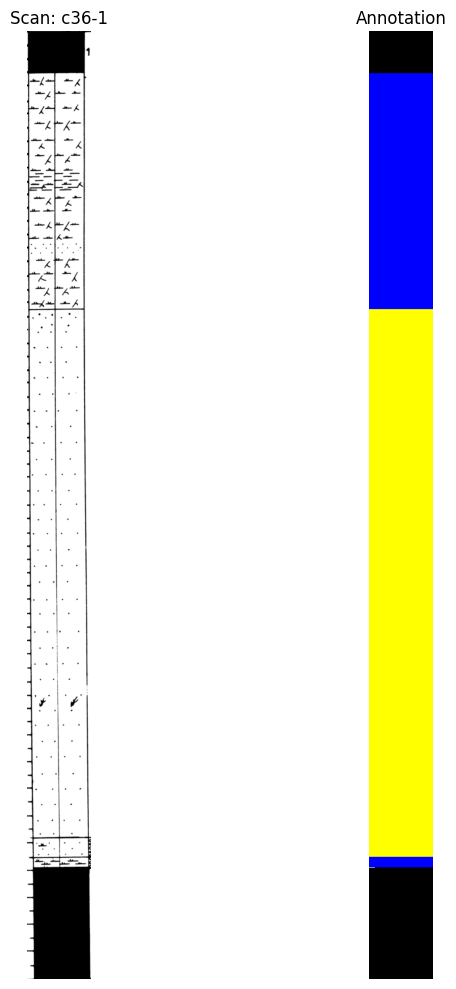

In [4]:
def find_pairs(data_dir: Path) -> list[dict[str, Path | str]]:
    pairs = []
    for scan_path in sorted(data_dir.glob('*.png')):
        if scan_path.name.endswith('-labeled.png'):
            continue
        mask_path = scan_path.with_name(f'{scan_path.stem}-labeled.png')
        if mask_path.exists():
            pairs.append({'name': scan_path.stem, 'scan_path': scan_path, 'mask_path': mask_path})
    if not pairs:
        raise FileNotFoundError(f'No scan/mask pairs found in {data_dir}')
    return pairs


def load_rgb(path: Path) -> np.ndarray:
    return np.array(Image.open(path).convert('RGB'))


def encode_mask(mask_rgb: np.ndarray) -> np.ndarray:
    flat = mask_rgb.reshape(-1, 3).astype(np.int16)
    labels = np.full(flat.shape[0], -1, dtype=np.int64)
    for color, class_id in COLOR_TO_CLASS.items():
        matches = np.all(flat == np.array(color, dtype=np.int16), axis=1)
        labels[matches] = class_id
    missing = labels < 0
    if missing.any():
        palette = PALETTE.astype(np.int16)
        distances = ((flat[missing, None, :] - palette[None, :, :]) ** 2).sum(axis=2)
        labels[missing] = distances.argmin(axis=1)
    return labels.reshape(mask_rgb.shape[:2])


def decode_mask(mask_idx: np.ndarray) -> np.ndarray:
    return PALETTE[mask_idx]


def overlay_prediction(scan_rgb: np.ndarray, mask_idx: np.ndarray, alpha: float = 0.45) -> np.ndarray:
    colors = decode_mask(mask_idx).astype(np.float32)
    scan = scan_rgb.astype(np.float32)
    overlay = scan * (1.0 - alpha) + colors * alpha
    return np.clip(overlay, 0, 255).astype(np.uint8)


def plot_pair(pair: dict[str, Path | str], max_height: int = 1800) -> None:
    scan = load_rgb(pair['scan_path'])
    mask = load_rgb(pair['mask_path'])
    if scan.shape[0] > max_height:
        ratio = max_height / scan.shape[0]
        new_size = (max(1, int(scan.shape[1] * ratio)), max_height)
        scan = np.array(Image.fromarray(scan).resize(new_size, Image.Resampling.BILINEAR))
        mask = np.array(Image.fromarray(mask).resize(new_size, Image.Resampling.NEAREST))
    fig, axes = plt.subplots(1, 2, figsize=(10, 10))
    axes[0].imshow(scan)
    axes[0].set_title(f"Scan: {pair['name']}")
    axes[1].imshow(mask)
    axes[1].set_title('Annotation')
    for ax in axes:
        ax.axis('off')
    plt.tight_layout()


pairs = find_pairs(DATA_DIR)
summary_rows = []
for pair in pairs:
    scan = load_rgb(pair['scan_path'])
    mask = load_rgb(pair['mask_path'])
    colors = np.unique(mask.reshape(-1, 3), axis=0)
    summary_rows.append({
        'name': pair['name'],
        'height': int(scan.shape[0]),
        'width': int(scan.shape[1]),
        'mask_matches_scan': bool(scan.shape == mask.shape),
        'mask_colors': [CLASS_NAME_BY_ID[COLOR_TO_CLASS.get(tuple(color.tolist()), 0)] for color in colors],
    })
summary_df = pd.DataFrame(summary_rows).sort_values('name').reset_index(drop=True)
display(summary_df)
plot_pair(pairs[0])

In [5]:
val_count = max(1, int(round(len(pairs) * VAL_FRACTION)))
train_pairs = pairs[:-val_count] if len(pairs) > val_count else pairs
val_pairs = pairs[-val_count:] if len(pairs) > 1 else pairs
print('Train:', [pair['name'] for pair in train_pairs])
print('Val:  ', [pair['name'] for pair in val_pairs])


def pad_rgb_pair(scan_rgb: np.ndarray, mask_rgb: np.ndarray, min_height: int, min_width: int) -> tuple[np.ndarray, np.ndarray]:
    pad_h = max(0, min_height - scan_rgb.shape[0])
    pad_w = max(0, min_width - scan_rgb.shape[1])
    if pad_h == 0 and pad_w == 0:
        return scan_rgb, mask_rgb
    scan_rgb = np.pad(scan_rgb, ((0, pad_h), (0, pad_w), (0, 0)), constant_values=255)
    mask_rgb = np.pad(mask_rgb, ((0, pad_h), (0, pad_w), (0, 0)), constant_values=255)
    return scan_rgb, mask_rgb


def build_input_tensor(scan_rgb: np.ndarray) -> torch.Tensor:
    scan = scan_rgb.astype(np.float32) / 255.0
    if USE_GRAYSCALE_PLUS_EDGES:
        gray = scan.mean(axis=2, keepdims=True)
        grad_y = np.abs(np.gradient(gray[..., 0], axis=0))[..., None]
        grad_x = np.abs(np.gradient(gray[..., 0], axis=1))[..., None]
        features = np.concatenate([gray, grad_y, grad_x], axis=2)
    else:
        features = scan
    features = (features - 0.5) / 0.5
    return torch.from_numpy(features.transpose(2, 0, 1).astype(np.float32))


def augment_scan(scan_rgb: np.ndarray) -> np.ndarray:
    scan = scan_rgb.astype(np.float32)
    if random.random() < 0.8:
        scale = random.uniform(0.85, 1.15)
        bias = random.uniform(-12.0, 12.0)
        scan = scan * scale + bias
    return np.clip(scan, 0, 255).astype(np.uint8)


class BoreholePatchDataset(Dataset):
    def __init__(self, pairs: list[dict[str, Path | str]], patch_height: int = PATCH_HEIGHT, patch_width: int = PATCH_WIDTH, patches_per_image: int = TRAIN_PATCHES_PER_IMAGE) -> None:
        self.patch_height = patch_height
        self.patch_width = patch_width
        self.patches_per_image = patches_per_image
        self.images = []
        for pair in pairs:
            scan_rgb = load_rgb(pair['scan_path'])
            mask_rgb = load_rgb(pair['mask_path'])
            scan_rgb, mask_rgb = pad_rgb_pair(scan_rgb, mask_rgb, patch_height, patch_width)
            self.images.append({'name': pair['name'], 'scan': scan_rgb, 'mask': encode_mask(mask_rgb)})

    def __len__(self) -> int:
        return max(1, len(self.images) * self.patches_per_image)

    def __getitem__(self, index: int) -> tuple[torch.Tensor, torch.Tensor]:
        item = self.images[index % len(self.images)]
        scan_rgb = item['scan']
        mask = item['mask']
        height, width = mask.shape
        top = 0 if height == self.patch_height else random.randint(0, height - self.patch_height)
        left = 0 if width == self.patch_width else random.randint(0, width - self.patch_width)
        for _ in range(10):
            candidate = mask[top:top + self.patch_height, left:left + self.patch_width]
            if (candidate != 0).mean() > 0.05:
                break
            top = 0 if height == self.patch_height else random.randint(0, height - self.patch_height)
            left = 0 if width == self.patch_width else random.randint(0, width - self.patch_width)
        scan_patch = scan_rgb[top:top + self.patch_height, left:left + self.patch_width]
        mask_patch = mask[top:top + self.patch_height, left:left + self.patch_width]
        if random.random() < 0.5:
            scan_patch = np.ascontiguousarray(scan_patch[:, ::-1])
            mask_patch = np.ascontiguousarray(mask_patch[:, ::-1])
        scan_patch = augment_scan(scan_patch)
        return build_input_tensor(scan_patch), torch.from_numpy(mask_patch.astype(np.int64))


train_dataset = BoreholePatchDataset(train_pairs)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=(DEVICE.type == 'cuda'))
example_batch = next(iter(train_loader))
example_batch[0].shape, example_batch[1].shape

Train: ['c36-1', 'c36-2', 'c36-3', 'c37-1']
Val:   ['c37-2', 'c37-3']


(torch.Size([4, 3, 768, 192]), torch.Size([4, 768, 192]))

In [6]:
def make_group_norm(channels: int) -> nn.GroupNorm:
    for groups in (8, 4, 2, 1):
        if channels % groups == 0:
            return nn.GroupNorm(groups, channels)
    return nn.GroupNorm(1, channels)


class ConvBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int) -> None:
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            make_group_norm(out_channels),
            nn.GELU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            make_group_norm(out_channels),
            nn.GELU(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)


class UpBlock(nn.Module):
    def __init__(self, in_channels: int, skip_channels: int, out_channels: int) -> None:
        super().__init__()
        self.conv = ConvBlock(in_channels + skip_channels, out_channels)

    def forward(self, x: torch.Tensor, skip: torch.Tensor) -> torch.Tensor:
        x = F.interpolate(x, size=skip.shape[-2:], mode='bilinear', align_corners=False)
        x = torch.cat([x, skip], dim=1)
        return self.conv(x)


class SmallUNet(nn.Module):
    def __init__(self, in_channels: int = INPUT_CHANNELS, num_classes: int = NUM_CLASSES, base_channels: int = 24) -> None:
        super().__init__()
        self.enc1 = ConvBlock(in_channels, base_channels)
        self.enc2 = ConvBlock(base_channels, base_channels * 2)
        self.enc3 = ConvBlock(base_channels * 2, base_channels * 4)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = ConvBlock(base_channels * 4, base_channels * 8)
        self.up3 = UpBlock(base_channels * 8, base_channels * 4, base_channels * 4)
        self.up2 = UpBlock(base_channels * 4, base_channels * 2, base_channels * 2)
        self.up1 = UpBlock(base_channels * 2, base_channels, base_channels)
        self.head = nn.Conv2d(base_channels, num_classes, kernel_size=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        s1 = self.enc1(x)
        s2 = self.enc2(self.pool(s1))
        s3 = self.enc3(self.pool(s2))
        b = self.bottleneck(self.pool(s3))
        x = self.up3(b, s3)
        x = self.up2(x, s2)
        x = self.up1(x, s1)
        return self.head(x)


model = SmallUNet().to(DEVICE)
sum(parameter.numel() for parameter in model.parameters())

1096734

In [7]:
def compute_class_weights(images: list[dict[str, np.ndarray | str]]) -> torch.Tensor:
    counts = np.zeros(NUM_CLASSES, dtype=np.float64)
    for item in images:
        counts += np.bincount(item['mask'].reshape(-1), minlength=NUM_CLASSES)
    weights = counts.sum() / np.maximum(counts, 1.0)
    weights = weights / weights.mean()
    return torch.tensor(weights, dtype=torch.float32, device=DEVICE)


def soft_dice_loss(logits: torch.Tensor, target: torch.Tensor, eps: float = 1e-6) -> torch.Tensor:
    probabilities = logits.softmax(dim=1)
    target_one_hot = F.one_hot(target, num_classes=NUM_CLASSES).permute(0, 3, 1, 2).float()
    intersection = (probabilities * target_one_hot).sum(dim=(0, 2, 3))
    denominator = probabilities.sum(dim=(0, 2, 3)) + target_one_hot.sum(dim=(0, 2, 3))
    dice = (2.0 * intersection + eps) / (denominator + eps)
    if len(dice) > 1:
        dice = dice[1:]
    return 1.0 - dice.mean()


def sliding_positions(size: int, patch: int, stride: int) -> list[int]:
    if size <= patch:
        return [0]
    positions = list(range(0, size - patch + 1, stride))
    if positions[-1] != size - patch:
        positions.append(size - patch)
    return positions


def make_blend_window(height: int, width: int, floor: float = 0.25) -> np.ndarray:
    y = np.ones(height, dtype=np.float32) if height <= 2 else np.hanning(height).astype(np.float32)
    x = np.ones(width, dtype=np.float32) if width <= 2 else np.hanning(width).astype(np.float32)
    return floor + (1.0 - floor) * np.outer(y, x)


@torch.no_grad()
def predict_full_mask(model: nn.Module, scan_rgb: np.ndarray) -> np.ndarray:
    scan_tensor = build_input_tensor(scan_rgb)
    _, orig_h, orig_w = scan_tensor.shape
    pad_h = max(0, PATCH_HEIGHT - orig_h)
    pad_w = max(0, PATCH_WIDTH - orig_w)
    if pad_h or pad_w:
        scan_tensor = F.pad(scan_tensor, (0, pad_w, 0, pad_h), value=1.0)
    _, padded_h, padded_w = scan_tensor.shape
    logits_acc = np.zeros((NUM_CLASSES, padded_h, padded_w), dtype=np.float32)
    weight_acc = np.zeros((padded_h, padded_w), dtype=np.float32)
    blend = make_blend_window(PATCH_HEIGHT, PATCH_WIDTH)
    for top in sliding_positions(padded_h, PATCH_HEIGHT, STRIDE_Y):
        for left in sliding_positions(padded_w, PATCH_WIDTH, STRIDE_X):
            patch = scan_tensor[:, top:top + PATCH_HEIGHT, left:left + PATCH_WIDTH].unsqueeze(0).to(DEVICE)
            logits = model(patch).softmax(dim=1).squeeze(0).cpu().numpy()
            logits_acc[:, top:top + PATCH_HEIGHT, left:left + PATCH_WIDTH] += logits * blend[None, :, :]
            weight_acc[top:top + PATCH_HEIGHT, left:left + PATCH_WIDTH] += blend
    logits_acc /= np.maximum(weight_acc[None, :, :], 1e-6)
    return logits_acc[:, :orig_h, :orig_w].argmax(axis=0).astype(np.uint8)


def confusion_from_masks(y_true: np.ndarray, y_pred: np.ndarray) -> np.ndarray:
    encoded = y_true.reshape(-1) * NUM_CLASSES + y_pred.reshape(-1)
    conf = np.bincount(encoded, minlength=NUM_CLASSES * NUM_CLASSES)
    return conf.reshape(NUM_CLASSES, NUM_CLASSES)


def summarize_confusion(confusion: np.ndarray) -> dict[str, object]:
    tp = np.diag(confusion).astype(np.float64)
    row_sum = confusion.sum(axis=1).astype(np.float64)
    col_sum = confusion.sum(axis=0).astype(np.float64)
    union = row_sum + col_sum - tp
    iou = np.divide(tp, union, out=np.zeros_like(tp), where=union > 0)
    return {
        'pixel_accuracy': float(tp.sum() / max(confusion.sum(), 1)),
        'mean_iou': float(iou[1:].mean()) if len(iou) > 1 else float(iou.mean()),
        'class_iou': {CLASS_NAME_BY_ID[idx]: float(iou[idx]) for idx in range(NUM_CLASSES)},
    }


def evaluate_pairs(model: nn.Module, pairs_to_score: list[dict[str, Path | str]]) -> tuple[pd.DataFrame, dict[str, object]]:
    total_conf = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int64)
    rows = []
    for pair in pairs_to_score:
        scan_rgb = load_rgb(pair['scan_path'])
        target = encode_mask(load_rgb(pair['mask_path']))
        prediction = predict_full_mask(model, scan_rgb)
        image_conf = confusion_from_masks(target, prediction)
        total_conf += image_conf
        stats = summarize_confusion(image_conf)
        rows.append({'name': pair['name'], 'pixel_accuracy': stats['pixel_accuracy'], 'mean_iou': stats['mean_iou']})
    return pd.DataFrame(rows), summarize_confusion(total_conf)


class_weights = compute_class_weights(train_dataset.images)
criterion_ce = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)


def loss_fn(logits: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    return 0.7 * criterion_ce(logits, target) + 0.3 * soft_dice_loss(logits, target)


def train_epoch(model: nn.Module, loader: DataLoader) -> float:
    model.train()
    running_loss = 0.0
    for inputs, targets in loader:
        inputs = inputs.to(DEVICE, non_blocking=True)
        targets = targets.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        logits = model(inputs)
        loss = loss_fn(logits, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
    return running_loss / max(len(loader.dataset), 1)

epoch=01 train_loss=1.1992 val_mIoU=0.3414 val_acc=0.6621
epoch=02 train_loss=1.0077 val_mIoU=0.3619 val_acc=0.7121
epoch=03 train_loss=0.8932 val_mIoU=0.3567 val_acc=0.6246
epoch=04 train_loss=0.7449 val_mIoU=0.4342 val_acc=0.7599
epoch=05 train_loss=0.6943 val_mIoU=0.4254 val_acc=0.7285
epoch=06 train_loss=0.6513 val_mIoU=0.4031 val_acc=0.7055
epoch=07 train_loss=0.5788 val_mIoU=0.4134 val_acc=0.7231
epoch=08 train_loss=0.5096 val_mIoU=0.4682 val_acc=0.7221
epoch=09 train_loss=0.4994 val_mIoU=0.4564 val_acc=0.7696
epoch=10 train_loss=0.5590 val_mIoU=0.4193 val_acc=0.7176
epoch=11 train_loss=0.4681 val_mIoU=0.4482 val_acc=0.7530
epoch=12 train_loss=0.5067 val_mIoU=0.4945 val_acc=0.7193
epoch=13 train_loss=0.4711 val_mIoU=0.4907 val_acc=0.7138
epoch=14 train_loss=0.4254 val_mIoU=0.5142 val_acc=0.7453
epoch=15 train_loss=0.4342 val_mIoU=0.5058 val_acc=0.7403


,epoch,train_loss,val_mean_iou,val_pixel_accuracy
0,1,1.199166,0.341390,0.662072
1,2,1.007710,0.361885,0.712056
2,3,0.893235,0.356709,0.624588
3,4,0.744921,0.434236,0.759934
4,5,0.694315,0.425435,0.728491
5,6,0.651263,0.403087,0.705484
6,7,0.578806,0.413374,0.723122
7,8,0.509604,0.468161,0.722127
8,9,0.499359,0.456400,0.769584
9,10,0.559024,0.419280,0.717628


,name,pixel_accuracy,mean_iou
0,c37-2,0.691686,0.443377
1,c37-3,0.956884,0.367878


{
  "pixel_accuracy": 0.7403070109687929,
  "mean_iou": 0.5057711276042894,
  "class_iou": {
    "background": 0.02114761791200929,
    "coal": 0.9193214502585237,
    "conglomerate": 0.48182579941288284,
    "sandstone": 0.5873483115989874,
    "siltstone": 0.5403600767510535,
    "claystone": 0.0
  }
}


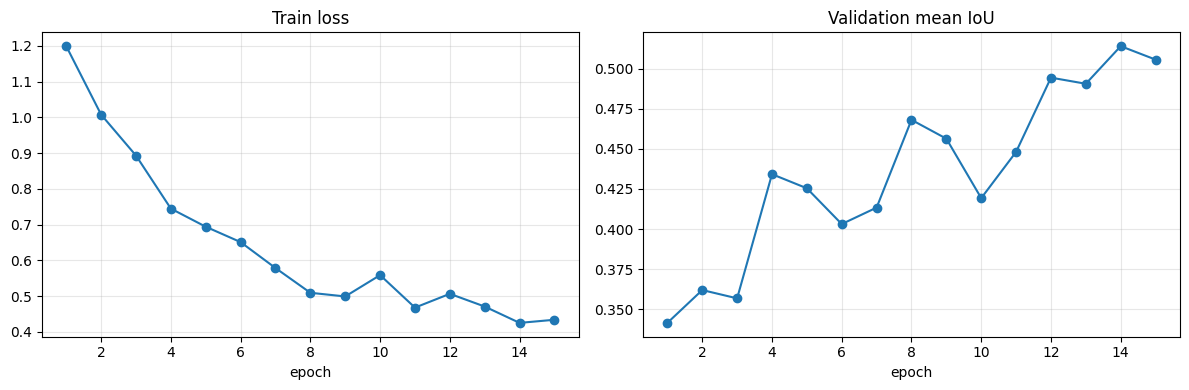

In [8]:
history = []
best_score = -float('inf')
best_state = None

for epoch in range(1, EPOCHS + 1):
    train_loss = train_epoch(model, train_loader)
    val_metrics_df, val_summary = evaluate_pairs(model, val_pairs)
    history.append({
        'epoch': epoch,
        'train_loss': train_loss,
        'val_mean_iou': float(val_summary['mean_iou']),
        'val_pixel_accuracy': float(val_summary['pixel_accuracy']),
    })
    print(
        f"epoch={epoch:02d} train_loss={train_loss:.4f} "
        f"val_mIoU={float(val_summary['mean_iou']):.4f} "
        f"val_acc={float(val_summary['pixel_accuracy']):.4f}"
    )
    if float(val_summary['mean_iou']) > best_score:
        best_score = float(val_summary['mean_iou'])
        best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}

if best_state is not None:
    model.load_state_dict(best_state)

torch.save({
    'state_dict': model.state_dict(),
    'class_info': CLASS_INFO,
    'config': {
        'patch_height': PATCH_HEIGHT,
        'patch_width': PATCH_WIDTH,
        'stride_y': STRIDE_Y,
        'stride_x': STRIDE_X,
    },
}, OUTPUT_DIR / 'borehole_unet.pt')

history_df = pd.DataFrame(history)
display(history_df)
display(val_metrics_df)
print(json.dumps(val_summary, indent=2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
history_df.plot(x='epoch', y='train_loss', ax=axes[0], marker='o', legend=False, title='Train loss')
history_df.plot(x='epoch', y='val_mean_iou', ax=axes[1], marker='o', legend=False, title='Validation mean IoU')
for ax in axes:
    ax.grid(alpha=0.3)
plt.tight_layout()

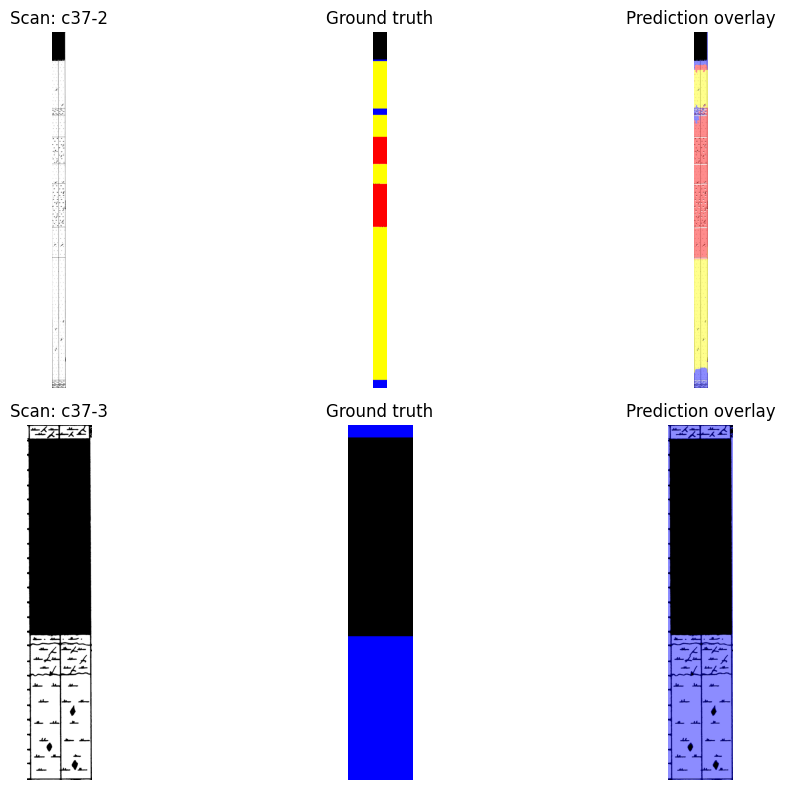

In [9]:
def plot_predictions(model: nn.Module, pairs_to_plot: list[dict[str, Path | str]], max_items: int = 2, max_height: int = 1800) -> None:
    selected = pairs_to_plot[:max_items]
    fig, axes = plt.subplots(len(selected), 3, figsize=(12, 4 * len(selected)))
    if len(selected) == 1:
        axes = np.expand_dims(axes, axis=0)
    for row_axes, pair in zip(axes, selected):
        scan_rgb = load_rgb(pair['scan_path'])
        target_rgb = load_rgb(pair['mask_path'])
        pred_idx = predict_full_mask(model, scan_rgb)
        pred_rgb = decode_mask(pred_idx)
        overlay = overlay_prediction(scan_rgb, pred_idx)
        if scan_rgb.shape[0] > max_height:
            ratio = max_height / scan_rgb.shape[0]
            new_size = (max(1, int(scan_rgb.shape[1] * ratio)), max_height)
            scan_rgb = np.array(Image.fromarray(scan_rgb).resize(new_size, Image.Resampling.BILINEAR))
            target_rgb = np.array(Image.fromarray(target_rgb).resize(new_size, Image.Resampling.NEAREST))
            pred_rgb = np.array(Image.fromarray(pred_rgb).resize(new_size, Image.Resampling.NEAREST))
            overlay = np.array(Image.fromarray(overlay).resize(new_size, Image.Resampling.BILINEAR))
        row_axes[0].imshow(scan_rgb)
        row_axes[0].set_title(f"Scan: {pair['name']}")
        row_axes[1].imshow(target_rgb)
        row_axes[1].set_title('Ground truth')
        row_axes[2].imshow(overlay)
        row_axes[2].set_title('Prediction overlay')
        for ax in row_axes:
            ax.axis('off')
    plt.tight_layout()


plot_predictions(model, val_pairs if val_pairs else pairs, max_items=min(2, len(val_pairs) if val_pairs else len(pairs)))

In [10]:
def dominant_row_class(mask_idx: np.ndarray, band_fraction: float = CENTER_BAND_FRACTION) -> np.ndarray:
    height, width = mask_idx.shape
    band_width = max(1, int(round(width * band_fraction)))
    left = max(0, (width - band_width) // 2)
    right = min(width, left + band_width)
    band = mask_idx[:, left:right]
    row_labels = np.zeros(height, dtype=np.uint8)
    for row in range(height):
        values = band[row]
        values = values[values != 0]
        if values.size == 0:
            row_labels[row] = 0
            continue
        counts = np.bincount(values, minlength=NUM_CLASSES)
        row_labels[row] = counts.argmax()
    return row_labels


def rows_to_intervals(row_labels: np.ndarray) -> list[dict[str, int | str]]:
    if len(row_labels) == 0:
        return []
    intervals = []
    start = 0
    current = int(row_labels[0])
    for index in range(1, len(row_labels) + 1):
        boundary = index == len(row_labels) or int(row_labels[index]) != current
        if not boundary:
            continue
        intervals.append({
            'top': int(start),
            'bottom': int(index - 1),
            'thickness': int(index - start),
            'class_id': int(current),
            'class_name': CLASS_NAME_BY_ID[int(current)],
        })
        if index < len(row_labels):
            start = index
            current = int(row_labels[index])
    return intervals


def mask_to_json(mask_idx: np.ndarray, image_name: str) -> dict[str, object]:
    row_labels = dominant_row_class(mask_idx)
    intervals = [interval for interval in rows_to_intervals(row_labels) if interval['class_id'] != 0]
    return {
        'image_name': image_name,
        'image_height': int(mask_idx.shape[0]),
        'image_width': int(mask_idx.shape[1]),
        'classes': CLASS_INFO,
        'intervals': intervals,
        'notes': {
            'background_class_id': 0,
            'row_summary_band_fraction': float(CENTER_BAND_FRACTION),
            'boundary_policy': 'Coal remains a normal class. Adjacent lithology runs are not merged across predicted coal rows.',
        },
    }


def save_prediction_outputs(model: nn.Module, pairs_to_export: list[dict[str, Path | str]], destination: Path | None = None) -> pd.DataFrame:
    destination = destination or (OUTPUT_DIR / 'predictions')
    destination.mkdir(parents=True, exist_ok=True)
    exported = []
    for pair in pairs_to_export:
        scan_rgb = load_rgb(pair['scan_path'])
        pred_idx = predict_full_mask(model, scan_rgb)
        pred_rgb = decode_mask(pred_idx)
        overlay = overlay_prediction(scan_rgb, pred_idx)
        payload = mask_to_json(pred_idx, pair['name'])
        mask_path = destination / f"{pair['name']}-predicted.png"
        overlay_path = destination / f"{pair['name']}-overlay.png"
        json_path = destination / f"{pair['name']}.json"
        Image.fromarray(pred_rgb).save(mask_path)
        Image.fromarray(overlay).save(overlay_path)
        json_path.write_text(json.dumps(payload, indent=2), encoding='utf-8')
        exported.append({
            'name': pair['name'],
            'mask_path': str(mask_path),
            'overlay_path': str(overlay_path),
            'json_path': str(json_path),
            'interval_count': len(payload['intervals']),
        })
    return pd.DataFrame(exported)


export_df = save_prediction_outputs(model, pairs)
display(export_df)
example_payload = mask_to_json(predict_full_mask(model, load_rgb(pairs[0]['scan_path'])), pairs[0]['name'])
example_payload['intervals'][:8]

,name,mask_path,overlay_path,json_path,interval_count
0,c36-1,outputs/boreholes_unet/predictions/c36-1-predi...,outputs/boreholes_unet/predictions/c36-1-overl...,outputs/boreholes_unet/predictions/c36-1.json,11
1,c36-2,outputs/boreholes_unet/predictions/c36-2-predi...,outputs/boreholes_unet/predictions/c36-2-overl...,outputs/boreholes_unet/predictions/c36-2.json,33
2,c36-3,outputs/boreholes_unet/predictions/c36-3-predi...,outputs/boreholes_unet/predictions/c36-3-overl...,outputs/boreholes_unet/predictions/c36-3.json,3
3,c37-1,outputs/boreholes_unet/predictions/c37-1-predi...,outputs/boreholes_unet/predictions/c37-1-overl...,outputs/boreholes_unet/predictions/c37-1.json,17
4,c37-2,outputs/boreholes_unet/predictions/c37-2-predi...,outputs/boreholes_unet/predictions/c37-2-overl...,outputs/boreholes_unet/predictions/c37-2.json,42
5,c37-3,outputs/boreholes_unet/predictions/c37-3-predi...,outputs/boreholes_unet/predictions/c37-3-overl...,outputs/boreholes_unet/predictions/c37-3.json,3


[{'top': 0,
  'bottom': 4,
  'thickness': 5,
  'class_id': 4,
  'class_name': 'siltstone'},
 {'top': 5,
  'bottom': 303,
  'thickness': 299,
  'class_id': 1,
  'class_name': 'coal'},
 {'top': 304,
  'bottom': 2016,
  'thickness': 1713,
  'class_id': 4,
  'class_name': 'siltstone'},
 {'top': 2017,
  'bottom': 2018,
  'thickness': 2,
  'class_id': 2,
  'class_name': 'conglomerate'},
 {'top': 2019,
  'bottom': 2053,
  'thickness': 35,
  'class_id': 4,
  'class_name': 'siltstone'},
 {'top': 2054,
  'bottom': 2065,
  'thickness': 12,
  'class_id': 2,
  'class_name': 'conglomerate'},
 {'top': 2066,
  'bottom': 2077,
  'thickness': 12,
  'class_id': 4,
  'class_name': 'siltstone'},
 {'top': 2078,
  'bottom': 2305,
  'thickness': 228,
  'class_id': 2,
  'class_name': 'conglomerate'}]

## Next Steps

If the first run is too noisy, the most useful next changes are more labeled profiles, leave-one-profile-out validation, or a dedicated separator class if the thin black lines should not stay in the coal class.